In [1]:
from dotenv import load_dotenv
import os

load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGCHAIN_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

#Langsmith Tracking And Tracing
os.environ["LANGCHAIN_PROJECT"] = os.getenv("LANGCHAIN_PROJECT")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ['HF_TOKEN']=os.getenv("HF_TOKEN")

In [2]:
from autogen_agentchat.agents import AssistantAgent
from autogen_ext.models.openai import OpenAIChatCompletionClient

model_client = OpenAIChatCompletionClient(model="gpt-4o")

agent_1 = AssistantAgent(name="Assistant", model_client=model_client)

In [11]:
result = await agent_1.run(task="who are you")

In [12]:
result.messages[-1].content

"I'm an AI assistant designed to help you with various tasks, answer questions, and provide information on a wide range of topics. If there's anything specific you'd like to know or discuss, feel free to ask!"

In [13]:
result = await agent_1.run(task="what was my last question")

In [14]:
result.messages[-1].content

'Your last question was "who are you." If you have any more questions or need assistance with something else, feel free to let me know!'

In [16]:
state  = await agent_1.save_state()

In [17]:
state

{'type': 'AssistantAgentState',
 'version': '1.0.0',
 'llm_context': {'messages': [{'content': 'who are you',
    'source': 'user',
    'type': 'UserMessage'},
   {'content': "I'm an AI assistant designed to help you with various tasks and answer your questions. I can provide information, assist with problem-solving, and interact in a conversational manner. Let me know how I can assist you today! TERMINATE",
    'thought': None,
    'source': 'Assistant',
    'type': 'AssistantMessage'},
   {'content': 'what was my last question',
    'source': 'user',
    'type': 'UserMessage'},
   {'content': "I'm sorry, but I don't have access to previous interactions or your personal data. Could you please repeat your question or let me know how I can assist you?",
    'thought': None,
    'source': 'Assistant',
    'type': 'AssistantMessage'},
   {'content': 'who are you', 'source': 'user', 'type': 'UserMessage'},
   {'content': "I'm an AI assistant designed to help you with various tasks, answer 


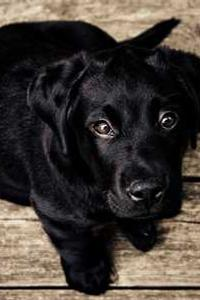

In [24]:
import PIL.Image
import requests
import PIL
from io import BytesIO
from autogen_core import Image
from autogen_agentchat.messages import MultiModalMessage

pil_image = PIL.Image.open(BytesIO(requests.get("https://picsum.photos/id/237/200/300").content))
image = Image(pil_image)
image

In [25]:
multimodal_message = MultiModalMessage(content=["can you describe what you see in the image?", image], source='user')
multimodal_message

MultiModalMessage(id='74ce13d7-ba0b-4eb5-9c8c-c287232c5d2d', source='user', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 7, 14, 0, 47, 24, 622200, tzinfo=datetime.timezone.utc), content=['can you describe what you see in the image?', <autogen_core._image.Image object at 0x1307dd590>], type='MultiModalMessage')

MultiModalMessage(id='74ce13d7-ba0b-4eb5-9c8c-c287232c5d2d', source='user', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 7, 14, 0, 47, 24, 622200, tzinfo=datetime.timezone.utc), content=['can you describe what you see in the image?', <autogen_core._image.Image object at 0x1307dd590>], type='MultiModalMessage')

In [27]:
result =await agent_1.run(task=multimodal_message)
result

TaskResult(messages=[MultiModalMessage(id='74ce13d7-ba0b-4eb5-9c8c-c287232c5d2d', source='user', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 7, 14, 0, 47, 24, 622200, tzinfo=datetime.timezone.utc), content=['can you describe what you see in the image?', <autogen_core._image.Image object at 0x1307dd590>], type='MultiModalMessage'), TextMessage(id='e66cb8e8-e735-4507-af3b-5818d124d90d', source='Assistant', models_usage=RequestUsage(prompt_tokens=500, completion_tokens=32), metadata={}, created_at=datetime.datetime(2025, 7, 14, 0, 49, 3, 783096, tzinfo=datetime.timezone.utc), content='The image shows a black puppy with shiny fur lying on a wooden surface. The puppy has dark eyes and is looking up, giving a cute and attentive expression.', type='TextMessage')], stop_reason=None)

"I'm an AI assistant designed to help you with various tasks, answer questions, and provide information on a wide range of topics. If there's anything specific you'd like to know or discuss, feel free to ask!"
'Your last question was "who are you." If you have any more questions or need assistance with something else, feel free to let me know!'
{'type': 'AssistantAgentState',
 'version': '1.0.0',
 'llm_context': {'messages': [{'content': 'who are you',
    'source': 'user',
    'type': 'UserMessage'},
   {'content': "I'm an AI assistant designed to help you with various tasks and answer your questions. I can provide information, assist with problem-solving, and interact in a conversational manner. Let me know how I can assist you today! TERMINATE",
    'thought': None,
    'source': 'Assistant',
    'type': 'AssistantMessage'},
   {'content': 'what was my last question',
    'source': 'user',
    'type': 'UserMessage'},
   {'content': "I'm sorry, but I don't have access to previous interactions or your personal data. Could you please repeat your question or let me know how I can assist you?",
    'thought': None,
    'source': 'Assistant',
    'type': 'AssistantMessage'},
   {'content': 'who are you', 'source': 'user', 'type': 'UserMessage'},
   {'content': "I'm an AI assistant designed to help you with various tasks, answer questions, and provide information on a wide range of topics. If there's anything specific you'd like to know or discuss, feel free to ask!",
    'thought': None,
    'source': 'Assistant',
    'type': 'AssistantMessage'},
   {'content': 'what was my last question',
    'source': 'user',
    'type': 'UserMessage'},
   {'content': 'Your last question was "who are you." If you have any more questions or need assistance with something else, feel free to let me know!',
    'thought': None,
    'source': 'Assistant',
    'type': 'AssistantMessage'}]}}

MultiModalMessage(id='74ce13d7-ba0b-4eb5-9c8c-c287232c5d2d', source='user', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 7, 14, 0, 47, 24, 622200, tzinfo=datetime.timezone.utc), content=['can you describe what you see in the image?', <autogen_core._image.Image object at 0x1307dd590>], type='MultiModalMessage')

TaskResult(messages=[MultiModalMessage(id='74ce13d7-ba0b-4eb5-9c8c-c287232c5d2d', source='user', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 7, 14, 0, 47, 24, 622200, tzinfo=datetime.timezone.utc), content=['can you describe what you see in the image?', <autogen_core._image.Image object at 0x1307dd590>], type='MultiModalMessage'), TextMessage(id='e66cb8e8-e735-4507-af3b-5818d124d90d', source='Assistant', models_usage=RequestUsage(prompt_tokens=500, completion_tokens=32), metadata={}, created_at=datetime.datetime(2025, 7, 14, 0, 49, 3, 783096, tzinfo=datetime.timezone.utc), content='The image shows a black puppy with shiny fur lying on a wooden surface. The puppy has dark eyes and is looking up, giving a cute and attentive expression.', type='TextMessage')], stop_reason=None

In [28]:
from pydantic import BaseModel

class PlanetInfo(BaseModel):
    name: str
    location: str
    distance: float

In [31]:
structured_model_client = OpenAIChatCompletionClient(
    model="gpt-4o",
    response_format=PlanetInfo,
)

agent_2 = AssistantAgent(name="assistant", model_client=structured_model_client)

In [34]:
resp = await agent_2.run(task="who are you")
print(resp)

messages=[TextMessage(id='aa140efc-3f1f-4b52-81a0-29b6e807c754', source='user', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 7, 14, 1, 6, 25, 804661, tzinfo=datetime.timezone.utc), content='who are you', type='TextMessage'), TextMessage(id='2184be9f-f904-48b6-ad0f-288787fe9503', source='assistant', models_usage=RequestUsage(prompt_tokens=132, completion_tokens=20), metadata={}, created_at=datetime.datetime(2025, 7, 14, 1, 6, 26, 709662, tzinfo=datetime.timezone.utc), content='{"name":"Earth","location":"Solar System, third planet from the Sun","distance":0}', type='TextMessage')] stop_reason=None


messages=[TextMessage(id='aa140efc-3f1f-4b52-81a0-29b6e807c754', source='user', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 7, 14, 1, 6, 25, 804661, tzinfo=datetime.timezone.utc), content='who are you', type='TextMessage'), 

TextMessage(id='2184be9f-f904-48b6-ad0f-288787fe9503', source='assistant', models_usage=RequestUsage(prompt_tokens=132, completion_tokens=20), metadata={}, created_at=datetime.datetime(2025, 7, 14, 1, 6, 26, 709662, tzinfo=datetime.timezone.utc), 

content='{"name":"Earth","location":"Solar System, third planet from the Sun","distance":0}', 

type='TextMessage')] stop_reason=None

In [35]:
resp = await agent_2.run(task="what is your name")
print(resp)

messages=[TextMessage(id='800b3804-dcdd-44bc-91f0-d9e8996f4689', source='user', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 7, 14, 1, 7, 14, 751382, tzinfo=datetime.timezone.utc), content='what is your name', type='TextMessage'), TextMessage(id='54bfea71-0cb4-4e66-8654-e00e8757a386', source='assistant', models_usage=RequestUsage(prompt_tokens=169, completion_tokens=16), metadata={}, created_at=datetime.datetime(2025, 7, 14, 1, 7, 16, 137534, tzinfo=datetime.timezone.utc), content='{"name":"AI Assistant","location":"Cyberspace","distance":0}', type='TextMessage')] stop_reason=None


messages=[TextMessage(id='800b3804-dcdd-44bc-91f0-d9e8996f4689', source='user', models_usage=None, metadata={}, created_at=datetime.datetime(2025, 7, 14, 1, 7, 14, 751382, tzinfo=datetime.timezone.utc), content='what is your name', type='TextMessage'), TextMessage(id='54bfea71-0cb4-4e66-8654-e00e8757a386', source='assistant', models_usage=RequestUsage(prompt_tokens=169, completion_tokens=16), metadata={}, created_at=datetime.datetime(2025, 7, 14, 1, 7, 16, 137534, tzinfo=datetime.timezone.utc), 
content='{"name":"AI Assistant","location":"Cyberspace","distance":0}', type='TextMessage')] stop_reason=None